## 1. Initialize necessary libraries

In [4]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection

In [6]:
credit_card_data = pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding

In [7]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [8]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4. Data Preparation

In [10]:
del credit_card_data["ID"]

In [11]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [12]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data["SEX"])
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [13]:
credit_card_data.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5. Model Building

In [14]:
X= credit_card_data.drop("DEFAULT", axis=1)
y= credit_card_data["DEFAULT"]

In [15]:
X.shape, y.shape

((30000, 23), (30000,))

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123, shuffle=True, stratify=y)

## 6. Model Training

In [17]:
adb_classifier = AdaBoostClassifier()
gb_classifier = GradientBoostingClassifier(n_estimators=50)
xgb_classifier = XGBClassifier(n_estimators=200)
lgb_classifier = LGBMClassifier(n_estimators=200)


In [18]:
%%time
adb_classifier.fit(X_train, y_train)

CPU times: total: 6.67 s
Wall time: 7.06 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [19]:
%%time
gb_classifier.fit(X_train, y_train)

CPU times: total: 17.2 s
Wall time: 18 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
%%time
xgb_classifier.fit(X_train, y_train)

CPU times: total: 8.84 s
Wall time: 1.93 s


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
%%time
lgb_classifier.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 12.6 s
Wall time: 8.67 s


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Model Testing

In [22]:
y_pred_adb = adb_classifier.predict(X_test)
y_pred_gb = gb_classifier.predict(X_test)
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_lgb = lgb_classifier.predict(X_test)

## 8. Model Evaluation

In [25]:
print("ADB Accuracy Score", round(accuracy_score(y_test, y_pred_adb),4))
print("GB Accuracy Score", round(accuracy_score(y_test, y_pred_gb),4))
print("XGB Accuracy Score", round(accuracy_score(y_test, y_pred_xgb),4))
print("LGB Accuracy Score", round(accuracy_score(y_test, y_pred_lgb),4))

ADB Accuracy Score 0.8218
GB Accuracy Score 0.8233
XGB Accuracy Score 0.811
LGB Accuracy Score 0.8228


In [26]:
print("ADB Precision Score", round(precision_score(y_test, y_pred_adb),4))
print("GB Precision Score", round(precision_score(y_test, y_pred_gb),4))
print("XGB Precision Score", round(precision_score(y_test, y_pred_xgb),4))
print("LGB Precision Score", round(precision_score(y_test, y_pred_lgb),4))

ADB Precision Score 0.7048
GB Precision Score 0.6949
XGB Precision Score 0.6265
LGB Precision Score 0.6902


In [27]:
print("ADB Recall Score", round(recall_score(y_test, y_pred_adb),4))
print("GB Recall Score", round(recall_score(y_test, y_pred_gb),4))
print("XGB Recall Score", round(recall_score(y_test, y_pred_xgb),4))
print("LGB Recall Score", round(recall_score(y_test, y_pred_lgb),4))

ADB Recall Score 0.3346
GB Recall Score 0.3587
XGB Recall Score 0.3602
LGB Recall Score 0.361


In [29]:
print("ADB Confusion Matrix", confusion_matrix(y_test, y_pred_adb))
print("GB Confusion Matrix", confusion_matrix(y_test, y_pred_gb))
print("XGB Confusion Matrix", confusion_matrix(y_test, y_pred_xgb))
print("LGB Confusion Matrix", confusion_matrix(y_test, y_pred_lgb))

ADB Confusion Matrix [[4487  186]
 [ 883  444]]
GB Confusion Matrix [[4464  209]
 [ 851  476]]
XGB Confusion Matrix [[4388  285]
 [ 849  478]]
LGB Confusion Matrix [[4458  215]
 [ 848  479]]


## Feature Importance

In [30]:
adb_feature_imp = adb_classifier.feature_importances_
gb_feature_imp = gb_classifier.feature_importances_
xgb_feature_imp = xgb_classifier.feature_importances_
lgb_feature_imp = lgb_classifier.feature_importances_

In [32]:
feature_importance_list = pd.DataFrame(data={"Features":X.columns,
                  "Adaboost_Features":adb_feature_imp,
                  "GB_Features":gb_feature_imp,
                  "XGB_Features": xgb_feature_imp,
                  "LGB_Features": lgb_feature_imp})
feature_importance_list

,Features,Adaboost_Features,GB_Features,XGB_Features,LGB_Features
0,LIMIT_BAL,0.057269,0.026852,0.024032,436
1,SEX,0.000000,0.001689,0.019036,82
2,EDUCATION,0.000000,0.002136,0.022150,132
3,MARRIAGE,0.017747,0.002796,0.022542,61
4,AGE,0.000000,0.003232,0.021023,462
5,PAY_1,0.513985,0.655314,0.318621,149
6,PAY_2,0.035080,0.093329,0.114238,74
7,PAY_3,0.052493,0.041462,0.055724,75
8,PAY_4,0.004686,0.016298,0.037206,57
9,PAY_5,0.017710,0.013810,0.040900,56


## Q1 : Display Top 10 Features of Adaboost

In [33]:
import seaborn as sns

In [37]:
adb_top_features = feature_importance_list.sort_values(by="Adaboost_Features", ascending=False)
top_10_adb_features = adb_top_features.head(10)
top_10_adb_features

,Features,Adaboost_Features,GB_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.318621,149
17,PAY_AMT1,0.087824,0.021428,0.026788,376
18,PAY_AMT2,0.064727,0.017985,0.024565,416
0,LIMIT_BAL,0.057269,0.026852,0.024032,436
7,PAY_3,0.052493,0.041462,0.055724,75
10,PAY_6,0.042327,0.018469,0.034584,74
19,PAY_AMT3,0.037968,0.020130,0.025592,380
6,PAY_2,0.035080,0.093329,0.114238,74
20,PAY_AMT4,0.019563,0.010408,0.023088,342
15,BILL_AMT5,0.018466,0.002390,0.023254,298


<Axes: xlabel='Adaboost_Features', ylabel='Features'>

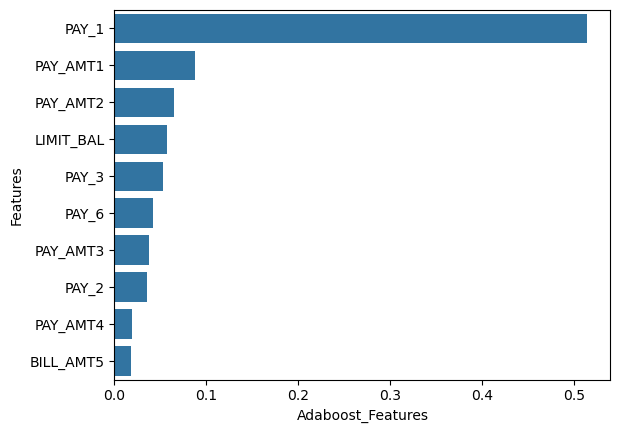

In [38]:
sns.barplot(data=top_10_adb_features, y="Features", x="Adaboost_Features")

In [34]:
gb_top_features = feature_importance_list.sort_values(by="GB_Features", ascending=False)
top_10_gb_features = gb_top_features.head(10)
top_10_gb_features

,Features,Adaboost_Features,GB_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.318621,149
6,PAY_2,0.035080,0.093329,0.114238,74
7,PAY_3,0.052493,0.041462,0.055724,75
0,LIMIT_BAL,0.057269,0.026852,0.024032,436
11,BILL_AMT1,0.014796,0.022708,0.026197,435
17,PAY_AMT1,0.087824,0.021428,0.026788,376
19,PAY_AMT3,0.037968,0.020130,0.025592,380
10,PAY_6,0.042327,0.018469,0.034584,74
18,PAY_AMT2,0.064727,0.017985,0.024565,416
8,PAY_4,0.004686,0.016298,0.037206,57


<Axes: xlabel='GB_Features', ylabel='Features'>

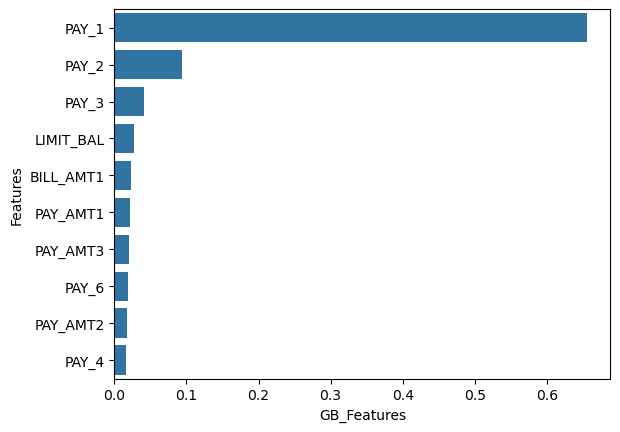

In [36]:
sns.barplot(data=top_10_gb_features, y="Features", x="GB_Features")

In [39]:
xgb_top_features = feature_importance_list.sort_values(by="XGB_Features", ascending=False)
top_10_xgb_features = xgb_top_features.head(10)
top_10_xgb_features

,Features,Adaboost_Features,GB_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.318621,149
6,PAY_2,0.035080,0.093329,0.114238,74
7,PAY_3,0.052493,0.041462,0.055724,75
9,PAY_5,0.017710,0.013810,0.040900,56
8,PAY_4,0.004686,0.016298,0.037206,57
10,PAY_6,0.042327,0.018469,0.034584,74
17,PAY_AMT1,0.087824,0.021428,0.026788,376
11,BILL_AMT1,0.014796,0.022708,0.026197,435
19,PAY_AMT3,0.037968,0.020130,0.025592,380
18,PAY_AMT2,0.064727,0.017985,0.024565,416


<Axes: xlabel='XGB_Features', ylabel='Features'>

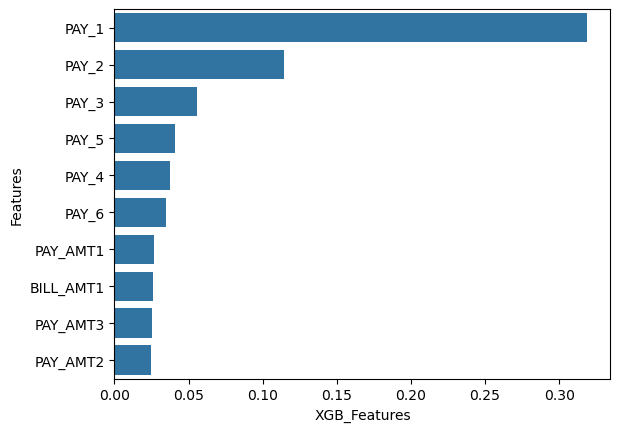

In [40]:
sns.barplot(data=top_10_xgb_features, y="Features", x="XGB_Features")

In [41]:
lgb_top_features = feature_importance_list.sort_values(by="LGB_Features", ascending=False)
top_10_lgb_features = lgb_top_features.head(10)
top_10_lgb_features

,Features,Adaboost_Features,GB_Features,XGB_Features,LGB_Features
22,PAY_AMT6,0.000000,0.008694,0.023531,475
4,AGE,0.000000,0.003232,0.021023,462
0,LIMIT_BAL,0.057269,0.026852,0.024032,436
11,BILL_AMT1,0.014796,0.022708,0.026197,435
18,PAY_AMT2,0.064727,0.017985,0.024565,416
19,PAY_AMT3,0.037968,0.020130,0.025592,380
17,PAY_AMT1,0.087824,0.021428,0.026788,376
21,PAY_AMT5,0.000000,0.004895,0.022632,346
20,PAY_AMT4,0.019563,0.010408,0.023088,342
12,BILL_AMT2,0.015358,0.006407,0.024528,331


<Axes: xlabel='LGB_Features', ylabel='Features'>

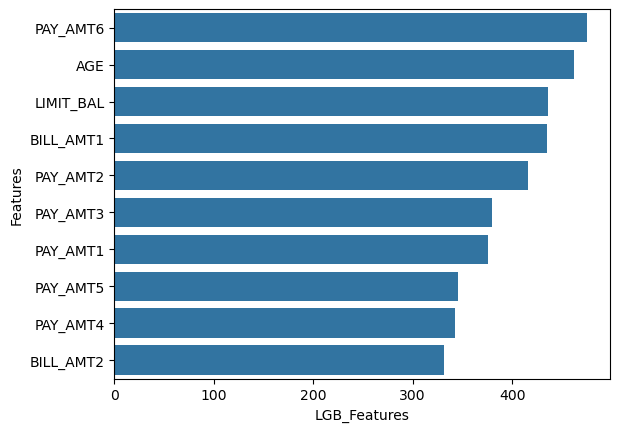

In [42]:
sns.barplot(data=top_10_lgb_features, y="Features", x="LGB_Features")

## THE END